In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No hay GPU disponible.")

PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: Tesla T4


In [ ]:
!pip install -q transformers datasets peft accelerate scikit-learn pandas matplotlib seaborn

In [ ]:
import pandas as pd

train_df = pd.read_csv("/content/ag_news_train.csv")
test_df = pd.read_csv("/content/ag_news_test.csv")

print("Train:", train_df.shape)
print("Test:", test_df.shape)

print("\nColumnas:")
print(train_df.columns.tolist())

print("\nPrimer registro:")
print(train_df.iloc[0])

Train: (8000, 2)
Test: (2000, 2)

Columnas:
['text', 'label']

Primer registro:
text     Red Hat Appoints New CFO. September 2, 2004 --...
label                                             Sci_Tech
Name: 0, dtype: object


In [ ]:
from datasets import Dataset

# Mapeo de categorías a números
label2id = {
    "Business": 0,
    "Sci_Tech": 1,
    "Sports": 2,
    "World": 3
}

id2label = {
    0: "Business",
    1: "Sci_Tech",
    2: "Sports",
    3: "World"
}

# Convertir las etiquetas de texto a enteros
train_df["label"] = train_df["label"].map(label2id)
test_df["label"] = test_df["label"].map(label2id)

# Convertir DataFrames a datasets de Hugging Face
train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

print("Train:", train_dataset)
print("Test:", test_dataset)

print("\nEjemplo:")
print(train_dataset[0])

print("\nDistribución de etiquetas:")
print(train_df["label"].value_counts().sort_index())

Train: Dataset({
    features: ['text', 'label'],
    num_rows: 8000
})
Test: Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})

Ejemplo:
{'text': 'Red Hat Appoints New CFO. September 2, 2004 -- (WEB HOST INDUSTRY REVIEW) -- Linux distributor Red Hat (redhat.com) announced on Thursday that it has appointed Charles E. Peters, Jr.', 'label': 1}

Distribución de etiquetas:
label
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "distilbert-base-uncased"

print("Cargando tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer cargado correctamente.")
print("Modelo:", MODEL_NAME)

Cargando tokenizer...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer cargado correctamente.
Modelo: distilbert-base-uncased


In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

print("Tokenizando TRAIN...")
train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenizando TEST...")
test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

print("\nTokenización finalizada.")

print("\nTRAIN:")
print(train_tokenized)

print("\nTEST:")
print(test_tokenized)

Tokenizando TRAIN...


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Tokenizando TEST...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]


Tokenización finalizada.

TRAIN:
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 8000
})

TEST:
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2000
})


In [ ]:
from transformers import AutoModelForSequenceClassification

print("Cargando modelo DistilBERT...")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

print("Modelo cargado correctamente.")
print("Cantidad de clases:", model.config.num_labels)
print("Clases:", model.config.id2label)

Cargando modelo DistilBERT...


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo cargado correctamente.
Cantidad de clases: 4
Clases: {0: 'Business', 1: 'Sci_Tech', 2: 'Sports', 3: 'World'}


In [ ]:
!pip install -q peft

In [ ]:
import peft
print("PEFT instalado correctamente:", peft.__version__)

PEFT instalado correctamente: 0.20.0


In [ ]:
!pip install -U "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 34.7 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
import torch
import peft
import torchao

print("PyTorch:", torch.__version__)
print("PEFT:", peft.__version__)
print("TorchAO:", torchao.__version__)
print("CUDA disponible:", torch.cuda.is_available())

PyTorch: 2.11.0+cu128
PEFT: 0.20.0
TorchAO: 0.18.0
CUDA disponible: True


In [ ]:
from peft import LoraConfig, TaskType, get_peft_model

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"],
    bias="none"
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 741,124 || all params: 67,697,672 || trainable%: 1.0948


In [ ]:
# Columnas que necesita el modelo
columns_to_keep = ["input_ids", "attention_mask", "label"]

train_tokenized = train_tokenized.remove_columns(
    [col for col in train_tokenized.column_names if col not in columns_to_keep]
)

test_tokenized = test_tokenized.remove_columns(
    [col for col in test_tokenized.column_names if col not in columns_to_keep]
)

print("Columnas TRAIN:")
print(train_tokenized.column_names)

print("\nColumnas TEST:")
print(test_tokenized.column_names)

print("\nEjemplo TRAIN:")
print(train_tokenized[0])

Columnas TRAIN:
['label', 'input_ids', 'attention_mask']

Columnas TEST:
['label', 'input_ids', 'attention_mask']

Ejemplo TRAIN:
{'label': 1, 'input_ids': [101, 2417, 6045, 16823, 2015, 2047, 12935, 2080, 1012, 2244, 1016, 1010, 2432, 1011, 1011, 1006, 4773, 3677, 3068, 3319, 1007, 1011, 1011, 11603, 16632, 2417, 6045, 1006, 2417, 12707, 1012, 4012, 1007, 2623, 2006, 9432, 2008, 2009, 2038, 2805, 2798, 1041, 1012, 12420, 1010, 3781, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    num_train_epochs=3,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    report_to="none",

    fp16=True
)

print("Configuración de entrenamiento creada correctamente.")

Configuración de entrenamiento creada correctamente.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics
)

print("Trainer creado correctamente.")

Trainer creado correctamente.


In [ ]:
import time

print("=" * 60)
print("INICIANDO ENTRENAMIENTO LoRA")
print("=" * 60)

inicio_entrenamiento = time.time()

train_result = trainer.train()

tiempo_entrenamiento = time.time() - inicio_entrenamiento

print("\n" + "=" * 60)
print("ENTRENAMIENTO FINALIZADO")
print("=" * 60)

print(f"Tiempo de entrenamiento: {tiempo_entrenamiento / 60:.2f} minutos")

print("\nEstadísticas finales:")
print(train_result.metrics)

INICIANDO ENTRENAMIENTO LoRA


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.747893,0.356279,0.884000,0.884659,0.884000,0.884186
2,0.339524,0.319989,0.886500,0.886747,0.886500,0.886553
3,0.320735,0.313100,0.892000,0.892514,0.892000,0.892136



ENTRENAMIENTO FINALIZADO
Tiempo de entrenamiento: 1.31 minutos

Estadísticas finales:
{'train_runtime': 77.8566, 'train_samples_per_second': 308.259, 'train_steps_per_second': 19.266, 'total_flos': 808493137920000.0, 'train_loss': 0.46938393147786456, 'epoch': 3.0}


EVALUACIÓN FINAL DEL MODELO LoRA



CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

    Business     0.8230    0.8460    0.8343       500
    Sci_Tech     0.8657    0.8640    0.8649       500
      Sports     0.9644    0.9740    0.9692       500
       World     0.9170    0.8840    0.9002       500

    accuracy                         0.8920      2000
   macro avg     0.8925    0.8920    0.8921      2000
weighted avg     0.8925    0.8920    0.8921      2000


MATRIZ DE CONFUSIÓN
------------------------------------------------------------
[[423  53   6  18]
 [ 48 432   2  18]
 [  6   3 487   4]
 [ 37  11  10 442]]


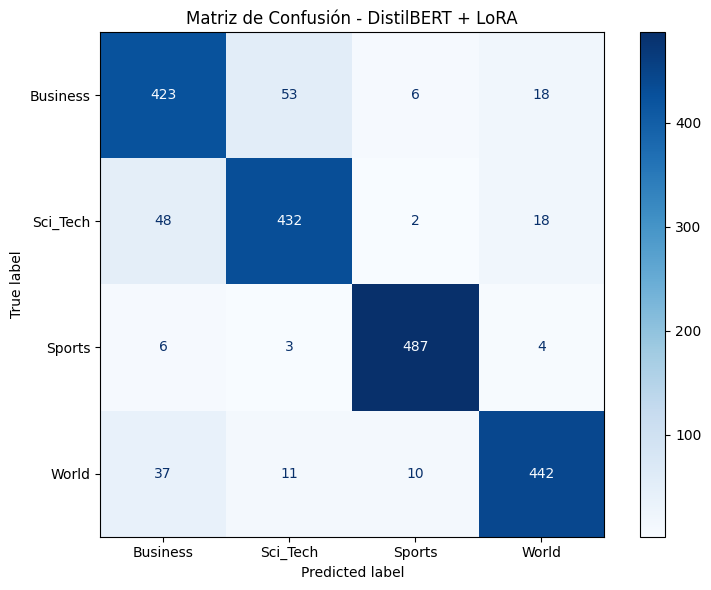


Matriz guardada como:
matriz_confusion_lora.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("=" * 60)
print("EVALUACIÓN FINAL DEL MODELO LoRA")
print("=" * 60)

# Obtener predicciones sobre TEST
predictions = trainer.predict(test_tokenized)

y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# Classification report
print("\nCLASSIFICATION REPORT")
print("-" * 60)

report = classification_report(
    y_true,
    y_pred,
    target_names=[
        "Business",
        "Sci_Tech",
        "Sports",
        "World"
    ],
    digits=4
)

print(report)

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

print("\nMATRIZ DE CONFUSIÓN")
print("-" * 60)
print(cm)

# Graficar matriz
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Business",
        "Sci_Tech",
        "Sports",
        "World"
    ]
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de Confusión - DistilBERT + LoRA")
plt.tight_layout()

plt.savefig(
    "matriz_confusion_lora.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nMatriz guardada como:")
print("matriz_confusion_lora.png")

In [ ]:
import pandas as pd
import os

# Crear carpeta de outputs
os.makedirs("outputs", exist_ok=True)

# Resultados finales del modelo LoRA
resultados_lora = {
    "modelo": "DistilBERT + LoRA",
    "accuracy": 0.8920,
    "precision_macro": 0.8925,
    "recall_macro": 0.8920,
    "f1_macro": 0.8921,
    "train_loss_final": 0.320735,
    "validation_loss_final": 0.313100,
    "tiempo_entrenamiento_min": 1.31,
    "parametros_totales": 67697672,
    "parametros_entrenables": 741124,
    "porcentaje_entrenable": 1.0948
}

df_lora = pd.DataFrame([resultados_lora])

df_lora.to_csv(
    "outputs/resultados_lora.csv",
    index=False
)

print("=" * 60)
print("RESULTADOS LoRA GUARDADOS")
print("=" * 60)
print(df_lora.to_string(index=False))
print("\nArchivo guardado en: outputs/resultados_lora.csv")

RESULTADOS LoRA GUARDADOS
           modelo  accuracy  precision_macro  recall_macro  f1_macro  train_loss_final  validation_loss_final  tiempo_entrenamiento_min  parametros_totales  parametros_entrenables  porcentaje_entrenable
DistilBERT + LoRA     0.892           0.8925         0.892    0.8921          0.320735                 0.3131                      1.31            67697672                  741124                 1.0948

Archivo guardado en: outputs/resultados_lora.csv


In [ ]:
import pandas as pd
import os

os.makedirs("outputs", exist_ok=True)

comparacion = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1-Score Macro"
    ],
    "TF-IDF + LinearSVC": [
        0.8935,
        0.89,
        0.89,
        0.89
    ],
    "DistilBERT + LoRA": [
        0.8920,
        0.8925,
        0.8920,
        0.8921
    ]
})

print("=" * 60)
print("COMPARACIÓN FINAL DE MODELOS")
print("=" * 60)
print(comparacion.to_string(index=False))

comparacion.to_csv(
    "outputs/comparacion_modelos.csv",
    index=False
)

print("\nTabla guardada en: outputs/comparacion_modelos.csv")

COMPARACIÓN FINAL DE MODELOS
        Métrica  TF-IDF + LinearSVC  DistilBERT + LoRA
       Accuracy              0.8935             0.8920
Precision Macro              0.8900             0.8925
   Recall Macro              0.8900             0.8920
 F1-Score Macro              0.8900             0.8921

Tabla guardada en: outputs/comparacion_modelos.csv


4. Conclusiones

La comparación entre ambos enfoques muestra que DistilBERT con LoRA alcanzó un rendimiento muy similar al modelo clásico basado en TF-IDF y LinearSVC. El modelo TF-IDF obtuvo una accuracy de 0,8935, mientras que DistilBERT + LoRA alcanzó 0,8920. En términos de F1-Score Macro, el modelo con LoRA obtuvo 0,8921 frente a 0,8900 del baseline.

Si bien DistilBERT + LoRA no produjo una mejora significativa en accuracy, consiguió un rendimiento comparable utilizando una fracción muy pequeña de los parámetros del modelo. De los 67.697.672 parámetros totales, solamente 741.124 fueron entrenables, equivalentes al 1,0948%.

El entrenamiento se realizó utilizando una GPU Tesla T4 y tuvo una duración aproximada de 1,31 minutos para tres épocas. Esto demuestra una de las principales ventajas de LoRA: permite adaptar un modelo Transformer manteniendo la mayor parte de sus parámetros congelados y reduciendo considerablemente la cantidad de parámetros que deben actualizarse.

Para este dataset y tamaño de entrenamiento, el modelo TF-IDF + LinearSVC continúa siendo una alternativa muy competitiva debido a su simplicidad y bajo costo computacional. Sin embargo, DistilBERT + LoRA demuestra que es posible utilizar técnicas modernas de fine-tuning eficiente obteniendo resultados prácticamente equivalentes con solamente el 1,0948% de los parámetros entrenables.

Por lo tanto, en este experimento el costo computacional adicional del Transformer no se justifica por una mejora de rendimiento, ya que el baseline clásico obtuvo una accuracy ligeramente superior. No obstante, LoRA resulta una estrategia eficiente para adaptar modelos Transformer y constituye una alternativa especialmente interesante cuando se requiere aprovechar representaciones contextuales más avanzadas o trabajar posteriormente con tareas y datasets de mayor complejidad.